# APO-HOLO Data Collection and Analysis

This notebook:
1. Scrapes the APO-HOLO table from D3Pharma
2. Performs basic analysis and visualization
3. Downloads PDB files and separates APO and HOLO chains

In [9]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import urllib3
from tqdm.auto import tqdm
import os

from sklearn.model_selection import train_test_split

# Disable SSL warnings for the D3Pharma site
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings('ignore')

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Scrape the APO-HOLO Table

In [10]:
def scrape_apoholo_table(url='https://www.d3pharma.com/D3PM/overall_apo_com.php'):
    """
    Scrape the APO-HOLO table from D3Pharma website.
    
    Returns:
        pd.DataFrame: DataFrame containing the scraped table data
    """
    print(f"Fetching data from {url}...")
    
    # Add headers to mimic a browser request
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.5',
        'Accept-Encoding': 'gzip, deflate, br',
        'Connection': 'keep-alive',
        'Upgrade-Insecure-Requests': '1'
    }
    
    # Fetch the webpage (disable SSL verification due to certificate issues)
    response = requests.get(url, headers=headers, verify=False, timeout=30)
    response.raise_for_status()
    
    # Parse HTML
    soup = BeautifulSoup(response.content, 'html.parser')
    
    # Find the table (adjust selector based on actual HTML structure)
    table = soup.find('table')
    
    if not table:
        raise ValueError("No table found on the page")
    
    # Extract headers
    headers = []
    header_row = table.find('tr')
    if header_row:
        headers = [th.get_text(strip=True) for th in header_row.find_all(['th', 'td'])]
    
    # Extract data rows
    rows = []
    for tr in table.find_all('tr')[1:]:  # Skip header row
        cells = tr.find_all(['td', 'th'])
        row = [cell.get_text(strip=True) for cell in cells]
        if row:  # Only add non-empty rows
            rows.append(row)
    
    # Create DataFrame
    if not headers:
        df = pd.DataFrame(rows)
    else:
        df = pd.DataFrame(rows, columns=headers)
    
    print(f"Successfully scraped {len(df)} entries")
    return df

In [11]:
# Scrape the table
df = scrape_apoholo_table()
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head(10)

Fetching data from https://www.d3pharma.com/D3PM/overall_apo_com.php...
Successfully scraped 4330 entries

DataFrame shape: (4330, 7)

Column names: ['uniprot ID', 'structure free', 'structure bound', 'ligand', 'RMSD overall', 'RMSD pocket', 'DrugBank target']


,uniprot ID,structure free,structure bound,ligand,RMSD overall,RMSD pocket,DrugBank target
0,A0A010,5B02_B,5GWW_D,7B5,5.01,3.43,
1,A0A010,5B02_B,5B03_D,GPP,5.11,0.24,
2,A0A0D3RJT7,5OJX_A,5OJY_A,9XB,7.68,4.97,
3,A0A0D5CVW2,5IHY_A,5DQW_B,ADP,2.54,1.03,
4,A0A0F6AY66,3VVX_B,3VW0_D,DEQ,2.16,2.49,
5,A0A0F6FJ34,4XE7_A,4XHN_A,ANP,3.9,3,
6,A0A0F6FJ34,4XE7_A,4XHO_A,ATP,3.89,2.53,
7,A0A0G9FES3,6B2O_E,6B2M_C,COA,2.2,2.39,
8,A0A0H2W8H3,3Q1H_A,5HI6_B,MTX,3.71,6.07,
9,A0A0H2X0S3,4MPB_B,4NEA_A,NAD,2.54,1,


In [12]:
# Save the raw data
output_dir = Path('data/apoholo')
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(output_dir / 'apoholo_raw_data.csv', index=False)
print(f"Saved raw data to {output_dir / 'apoholo_raw_data.csv'}")

Saved raw data to data/apoholo/apoholo_raw_data.csv


## 2. Data Cleaning and Exploration

In [13]:
# Display basic information
print("Dataset Info:")
print("=" * 50)
df.info()
print("\nBasic Statistics:")
print("=" * 50)
print(df.describe(include='all'))
print("\nMissing Values:")
print("=" * 50)
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4330 entries, 0 to 4329
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   uniprot ID       4330 non-null   object
 1   structure free   4330 non-null   object
 2   structure bound  4330 non-null   object
 3   ligand           4330 non-null   object
 4   RMSD overall     4330 non-null   object
 5   RMSD pocket      4330 non-null   object
 6   DrugBank target  4330 non-null   object
dtypes: object(7)
memory usage: 236.9+ KB

Basic Statistics:
       uniprot ID structure free structure bound ligand RMSD overall  \
count        4330           4330            4330   4330         4330   
unique       1643           2270            3627   2242          878   
top        E0SJQ4         2Q0C_B          6V03_C    ADP         2.01   
freq            5              5               5    392           48   

       RMSD pocket DrugBank target  
count         43

## 3. Basic Analysis and Visualization

In [14]:
# Plot 2: Numeric distributions (if any numeric columns exist)
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 0:
    n_cols = min(len(numeric_cols), 4)
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 4))
    
    if n_cols == 1:
        axes = [axes]
    
    for idx, col in enumerate(numeric_cols[:n_cols]):
        axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'numeric_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No numeric columns found for histogram plotting")

No numeric columns found for histogram plotting


In [15]:
# Summary statistics
print("\nSummary Statistics:")
print("=" * 80)
print(f"Total number of APO-HOLO pairs: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nColumn names and types:")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype} ({df[col].nunique()} unique values)")


Summary Statistics:
Total number of APO-HOLO pairs: 4330
Number of columns: 7

Column names and types:
  - uniprot ID: object (1643 unique values)
  - structure free: object (2270 unique values)
  - structure bound: object (3627 unique values)
  - ligand: object (2242 unique values)
  - RMSD overall: object (878 unique values)
  - RMSD pocket: object (791 unique values)
  - DrugBank target: object (46 unique values)


## 3.1 Count Unique PDB IDs

Before downloading, let's analyze how many unique PDB IDs we have for APO and HOLO structures.

In [16]:
# Count unique PDB IDs before downloading
print("\n" + "="*80)
print("Unique PDB ID Analysis")
print("="*80)

# Parse PDB IDs and chains from the format "5B02_B"
# Find columns that likely contain PDB IDs (looking for pattern like "XXXX_Y")
pdb_columns = []
for col in df.columns:
    sample_val = df[col].iloc[0] if len(df) > 0 else ""
    if isinstance(sample_val, str) and '_' in sample_val:
        pdb_columns.append(col)

print(f"\nColumns with PDB_Chain format: {pdb_columns}")

if len(pdb_columns) >= 2:
    apo_col = pdb_columns[0]  # Ligand-free (APO)
    holo_col = pdb_columns[1]  # Ligand-bound (HOLO)
    
    # Extract PDB IDs (before underscore) and chains (after underscore)
    df['apo_pdb_id'] = df[apo_col].str.split('_').str[0]
    df['apo_chain'] = df[apo_col].str.split('_').str[1]
    df['holo_pdb_id'] = df[holo_col].str.split('_').str[0]
    df['holo_chain'] = df[holo_col].str.split('_').str[1]
    
    # Count unique PDB IDs
    n_unique_apo = df['apo_pdb_id'].nunique()
    n_unique_holo = df['holo_pdb_id'].nunique()
    n_total_pairs = len(df)
    



Unique PDB ID Analysis

Columns with PDB_Chain format: ['structure free', 'structure bound']


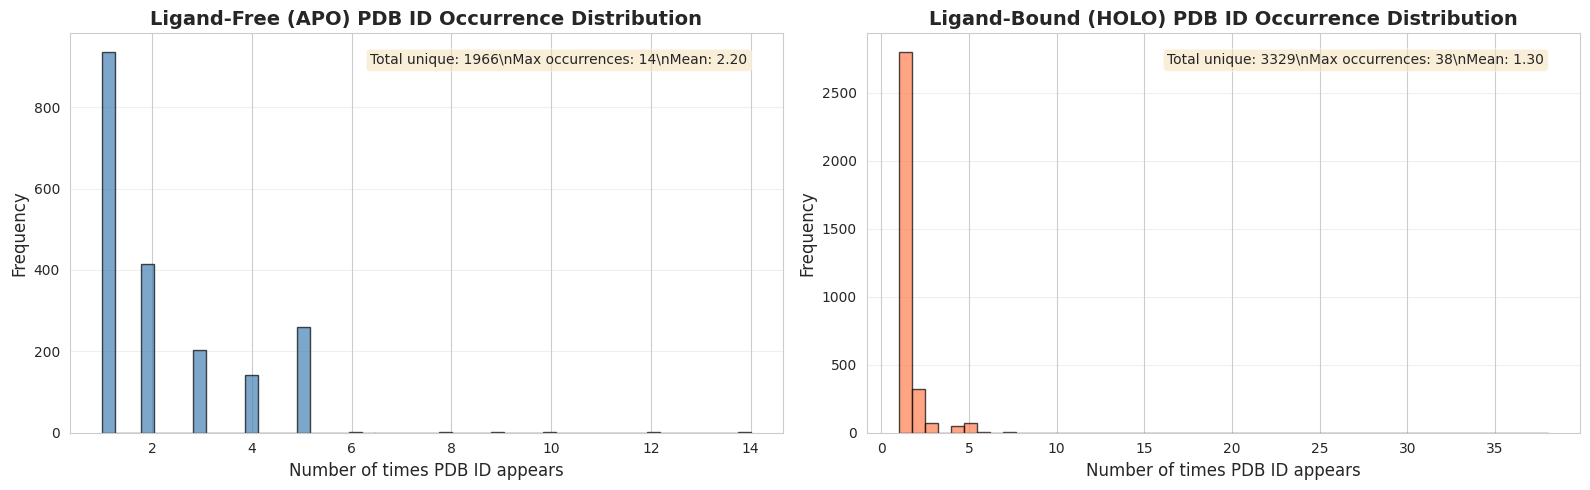


PDB ID Occurrence Statistics:

APO (Ligand-Free) PDB IDs:
  - Unique PDB IDs: 1966
  - Min occurrences: 1
  - Max occurrences: 14
  - Mean occurrences: 2.20
  - Median occurrences: 2.00

HOLO (Ligand-Bound) PDB IDs:
  - Unique PDB IDs: 3329
  - Min occurrences: 1
  - Max occurrences: 38
  - Mean occurrences: 1.30
  - Median occurrences: 1.00


In [17]:
# Histogram of PDB ID occurrence frequency for both APO and HOLO structures
if 'apo_pdb_id' in df.columns and 'holo_pdb_id' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # APO PDB ID frequency
    apo_counts = df['apo_pdb_id'].value_counts()
    axes[0].hist(apo_counts.values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Number of times PDB ID appears', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Ligand-Free (APO) PDB ID Occurrence Distribution', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].text(0.95, 0.95, f'Total unique: {len(apo_counts)}\\nMax occurrences: {apo_counts.max()}\\nMean: {apo_counts.mean():.2f}',
                 transform=axes[0].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # HOLO PDB ID frequency
    holo_counts = df['holo_pdb_id'].value_counts()
    axes[1].hist(holo_counts.values, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_xlabel('Number of times PDB ID appears', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Ligand-Bound (HOLO) PDB ID Occurrence Distribution', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].text(0.95, 0.95, f'Total unique: {len(holo_counts)}\\nMax occurrences: {holo_counts.max()}\\nMean: {holo_counts.mean():.2f}',
                 transform=axes[1].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(output_dir / 'pdb_id_occurrence_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("PDB ID Occurrence Statistics:")
    print("="*80)
    print(f"\nAPO (Ligand-Free) PDB IDs:")
    print(f"  - Unique PDB IDs: {len(apo_counts)}")
    print(f"  - Min occurrences: {apo_counts.min()}")
    print(f"  - Max occurrences: {apo_counts.max()}")
    print(f"  - Mean occurrences: {apo_counts.mean():.2f}")
    print(f"  - Median occurrences: {apo_counts.median():.2f}")
    
    print(f"\nHOLO (Ligand-Bound) PDB IDs:")
    print(f"  - Unique PDB IDs: {len(holo_counts)}")
    print(f"  - Min occurrences: {holo_counts.min()}")
    print(f"  - Max occurrences: {holo_counts.max()}")
    print(f"  - Mean occurrences: {holo_counts.mean():.2f}")
    print(f"  - Median occurrences: {holo_counts.median():.2f}")
else:
    print("ERROR: PDB IDs not parsed. Please run the 'Unique PDB ID Analysis' cell first.")

Analysis: APO-HOLO Pairs from Same vs Different PDBs

Total APO-HOLO pairs: 4330

Pairs from SAME PDB (different chains): 203 (4.7%)
Pairs from DIFFERENT PDBs: 4127 (95.3%)


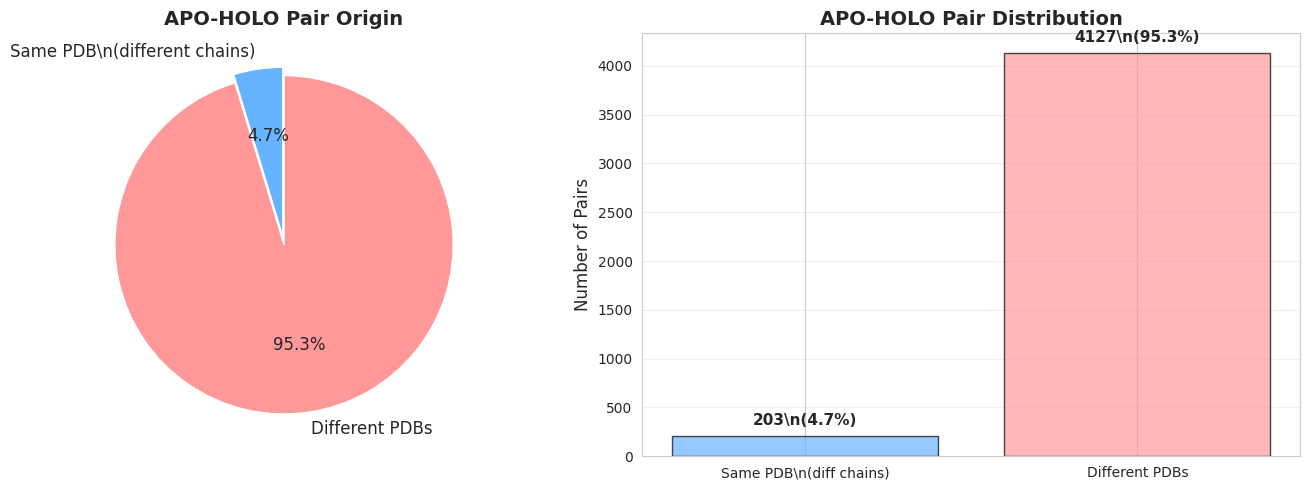


Examples of APO-HOLO pairs from the SAME PDB (different chains):
apo_pdb_id apo_chain holo_pdb_id holo_chain
      4XTT         B        4XTT          A
      4ZRB         C        4ZRB          H
      3I3Y         A        3I3Y          D
      3DOL         B        3DOL          A
      4G41         A        4G41          B
      4MH1         A        4MH1          B
      5OEA         F        5OEA          E
      4M2F         A        4M2F          C
      2AQ6         B        2AQ6          A
      1OI0         B        1OI0          A

Examples of APO-HOLO pairs from DIFFERENT PDBs:
apo_pdb_id apo_chain holo_pdb_id holo_chain
      5B02         B        5GWW          D
      5B02         B        5B03          D
      5OJX         A        5OJY          A
      5IHY         A        5DQW          B
      3VVX         B        3VW0          D
      4XE7         A        4XHN          A
      4XE7         A        4XHO          A
      6B2O         E        6B2M          C
     

In [18]:
# Analyze pairs that come from the same PDB (but different chains)
if 'apo_pdb_id' in df.columns and 'holo_pdb_id' in df.columns:
    # Check if APO and HOLO have the same PDB ID
    df['same_pdb'] = df['apo_pdb_id'] == df['holo_pdb_id']
    
    # Count pairs with same PDB ID
    n_same_pdb = df['same_pdb'].sum()
    n_diff_pdb = (~df['same_pdb']).sum()
    pct_same = 100 * n_same_pdb / len(df)
    
    print("="*80)
    print("Analysis: APO-HOLO Pairs from Same vs Different PDBs")
    print("="*80)
    print(f"\nTotal APO-HOLO pairs: {len(df)}")
    print(f"\nPairs from SAME PDB (different chains): {n_same_pdb} ({pct_same:.1f}%)")
    print(f"Pairs from DIFFERENT PDBs: {n_diff_pdb} ({100-pct_same:.1f}%)")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    colors = ['#66b3ff', '#ff9999']
    explode = (0.05, 0)
    axes[0].pie([n_same_pdb, n_diff_pdb], 
                labels=['Same PDB\\n(different chains)', 'Different PDBs'],
                autopct='%1.1f%%',
                startangle=90,
                colors=colors,
                explode=explode,
                textprops={'fontsize': 12})
    axes[0].set_title('APO-HOLO Pair Origin', fontsize=14, fontweight='bold')
    
    # Bar chart
    axes[1].bar(['Same PDB\\n(diff chains)', 'Different PDBs'], 
                [n_same_pdb, n_diff_pdb],
                color=colors,
                edgecolor='black',
                alpha=0.7)
    axes[1].set_ylabel('Number of Pairs', fontsize=12)
    axes[1].set_title('APO-HOLO Pair Distribution', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (v, label) in enumerate(zip([n_same_pdb, n_diff_pdb], ['Same PDB\\n(diff chains)', 'Different PDBs'])):
        axes[1].text(i, v + max(n_same_pdb, n_diff_pdb)*0.02, 
                     f'{v}\\n({100*v/len(df):.1f}%)',
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'same_pdb_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Show examples of pairs from the same PDB
    if n_same_pdb > 0:
        print(f"\n{'='*80}")
        print("Examples of APO-HOLO pairs from the SAME PDB (different chains):")
        print(f"{'='*80}")
        same_pdb_examples = df[df['same_pdb']][['apo_pdb_id', 'apo_chain', 'holo_pdb_id', 'holo_chain']].head(10)
        print(same_pdb_examples.to_string(index=False))
        
        # Check if any have the same chain too (would be unusual)
        same_pdb_same_chain = df[df['same_pdb'] & (df['apo_chain'] == df['holo_chain'])]
        if len(same_pdb_same_chain) > 0:
            print(f"\n⚠️  WARNING: Found {len(same_pdb_same_chain)} pairs with SAME PDB AND SAME CHAIN!")
            print("This is unusual - APO and HOLO should typically be different structures.")
            print(same_pdb_same_chain[['apo_pdb_id', 'apo_chain', 'holo_pdb_id', 'holo_chain']].head())
    
    if n_diff_pdb > 0:
        print(f"\n{'='*80}")
        print("Examples of APO-HOLO pairs from DIFFERENT PDBs:")
        print(f"{'='*80}")
        diff_pdb_examples = df[~df['same_pdb']][['apo_pdb_id', 'apo_chain', 'holo_pdb_id', 'holo_chain']].head(10)
        print(diff_pdb_examples.to_string(index=False))
    
    # Save updated dataframe with the 'same_pdb' flag
    df.to_csv(output_dir / 'apoholo_parsed_data.csv', index=False)
    print(f"\n{'='*80}")
    print(f"Updated data with 'same_pdb' flag saved to {output_dir / 'apoholo_parsed_data.csv'}")
    
else:
    print("ERROR: PDB IDs not parsed. Please run the 'Unique PDB ID Analysis' cell first.")

## 3.2 Ligand Frequency Analysis

Analyze which ligands appear most frequently in the dataset.

Ligand Frequency Analysis


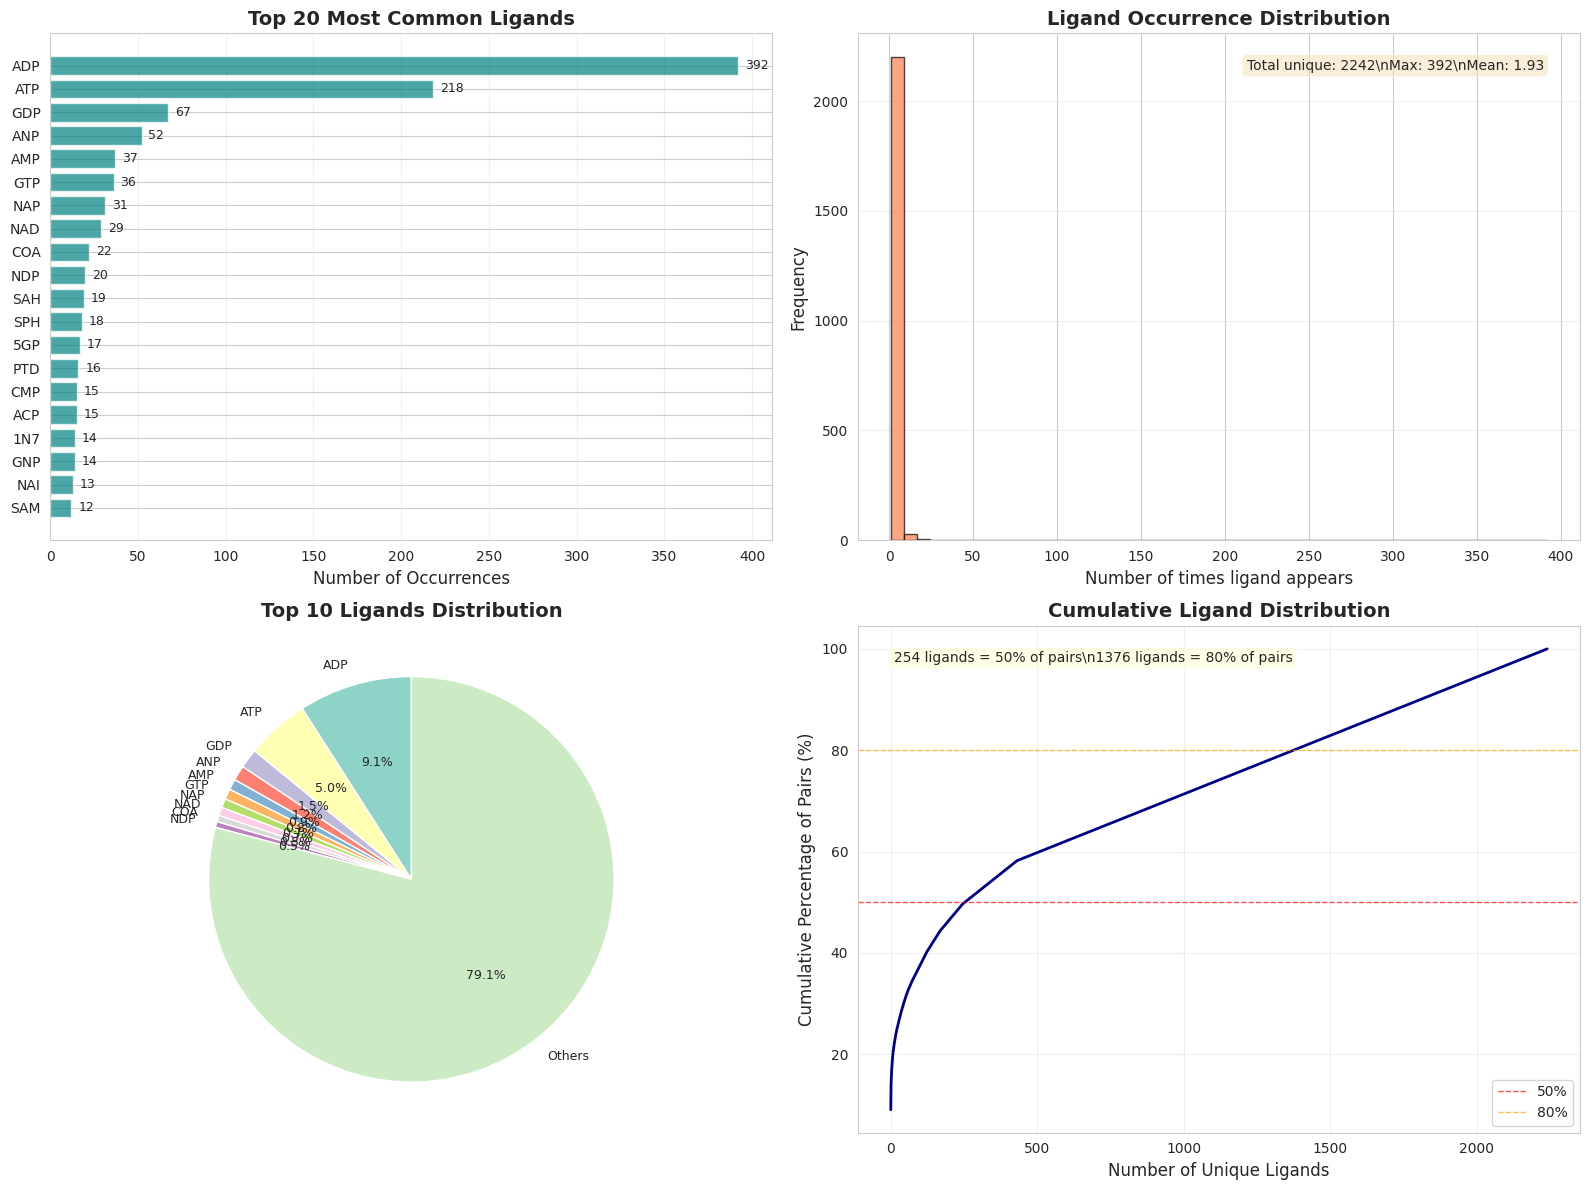


Key Insights:
  - 254 ligands (top 11.3%) account for 50% of all pairs
  - 1376 ligands (top 61.4%) account for 80% of all pairs
  - 1811 ligands (80.8%) appear only once

Updated data with 'ligand_frequency' column saved


In [19]:
# Analyze ligand frequency
print("="*80)
print("Ligand Frequency Analysis")
print("="*80)

# Count ligand occurrences
ligand_counts = df['ligand'].value_counts()


# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart of top 20 ligands
top_n = 20
top_ligands = ligand_counts.head(top_n)
axes[0, 0].barh(range(len(top_ligands)), top_ligands.values, color='teal', alpha=0.7)
axes[0, 0].set_yticks(range(len(top_ligands)))
axes[0, 0].set_yticklabels(top_ligands.index)
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel('Number of Occurrences', fontsize=12)
axes[0, 0].set_title(f'Top {top_n} Most Common Ligands', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_ligands.values):
    axes[0, 0].text(v + max(top_ligands.values)*0.01, i, str(v), 
                     va='center', fontsize=9)

# 2. Histogram of ligand occurrence frequency
axes[0, 1].hist(ligand_counts.values, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Number of times ligand appears', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Ligand Occurrence Distribution', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].text(0.95, 0.95, f'Total unique: {len(ligand_counts)}\\nMax: {ligand_counts.max()}\\nMean: {ligand_counts.mean():.2f}',
                transform=axes[0, 1].transAxes, fontsize=10, 
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Pie chart of top 10 ligands + "Others"
top_10 = ligand_counts.head(10)
others_count = ligand_counts[10:].sum()
pie_data = list(top_10.values) + [others_count]
pie_labels = list(top_10.index) + ['Others']
colors = plt.cm.Set3(range(len(pie_data)))

axes[1, 0].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90,
               colors=colors, textprops={'fontsize': 9})
axes[1, 0].set_title('Top 10 Ligands Distribution', fontsize=14, fontweight='bold')

# 4. Cumulative distribution
cumsum = ligand_counts.cumsum()
cumsum_pct = 100 * cumsum / cumsum.iloc[-1]
axes[1, 1].plot(range(len(cumsum_pct)), cumsum_pct.values, linewidth=2, color='darkblue')
axes[1, 1].axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50%')
axes[1, 1].axhline(y=80, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='80%')
axes[1, 1].set_xlabel('Number of Unique Ligands', fontsize=12)
axes[1, 1].set_ylabel('Cumulative Percentage of Pairs (%)', fontsize=12)
axes[1, 1].set_title('Cumulative Ligand Distribution', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

# Find how many ligands account for 50% and 80%
n_ligands_50 = (cumsum_pct >= 50).argmax() + 1
n_ligands_80 = (cumsum_pct >= 80).argmax() + 1
axes[1, 1].text(0.05, 0.95, 
                f'{n_ligands_50} ligands = 50% of pairs\\n{n_ligands_80} ligands = 80% of pairs',
                transform=axes[1, 1].transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(output_dir / 'ligand_frequency_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print(f"Key Insights:")
print(f"{'='*80}")
print(f"  - {n_ligands_50} ligands (top {100*n_ligands_50/len(ligand_counts):.1f}%) account for 50% of all pairs")
print(f"  - {n_ligands_80} ligands (top {100*n_ligands_80/len(ligand_counts):.1f}%) account for 80% of all pairs")
print(f"  - {ligand_counts[ligand_counts == 1].shape[0]} ligands ({100*ligand_counts[ligand_counts == 1].shape[0]/len(ligand_counts):.1f}%) appear only once")

# Add ligand frequency to dataframe
df['ligand_frequency'] = df['ligand'].map(ligand_counts)
df.to_csv(output_dir / 'apoholo_parsed_data.csv', index=False)
print(f"\n{'='*80}")
print(f"Updated data with 'ligand_frequency' column saved")

In [20]:
def download_pdb(pdb_id, output_dir='data/apoholo/pdb_files'):
    """
    Download a PDB file from RCSB PDB.
    
    Args:
        pdb_id: PDB identifier (e.g., '1ABC')
        output_dir: Directory to save the PDB file
    
    Returns:
        Path to downloaded file or None if failed
    """
    pdb_id = pdb_id.lower().strip()
    output_path = Path(output_dir) / f"{pdb_id}.pdb"
    
    # Check if already downloaded
    if output_path.exists():
        return output_path
    
    # Download from RCSB
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        
        # Create output directory if needed
        output_path.parent.mkdir(parents=True, exist_ok=True)
        
        # Save file
        with open(output_path, 'w') as f:
            f.write(response.text)
        
        return output_path
    
    except Exception as e:
        print(f"Failed to download {pdb_id}: {e}")
        return None


def extract_chain(pdb_file, chain_id, output_file):
    """
    Extract a specific chain from a PDB file.
    
    Args:
        pdb_file: Path to input PDB file
        chain_id: Chain identifier to extract
        output_file: Path to output PDB file
    """
    with open(pdb_file, 'r') as f_in, open(output_file, 'w') as f_out:
        for line in f_in:
            # Keep ATOM/HETATM lines for the specified chain
            if line.startswith(('ATOM', 'HETATM')):
                if len(line) > 21 and line[21] == chain_id:
                    f_out.write(line)
            # Keep header information
            elif line.startswith(('HEADER', 'TITLE', 'COMPND', 'SOURCE', 'REMARK')):
                f_out.write(line)
        
        # Add END record
        f_out.write("END\n")


def process_apoholo_pair(apo_id, apo_chain, holo_id, holo_chain, base_dir='data/apoholo'):
    """
    Download and separate APO and HOLO structures.
    
    Args:
        apo_id: PDB ID for APO structure
        apo_chain: Chain ID for APO structure
        holo_id: PDB ID for HOLO structure
        holo_chain: Chain ID for HOLO structure
        base_dir: Base directory for output
    
    Returns:
        Tuple of (apo_file, holo_file) paths or (None, None) if failed
    """
    base_path = Path(base_dir)
    pdb_dir = base_path / 'pdb_files'
    apo_dir = base_path / 'apo_chains'
    holo_dir = base_path / 'holo_chains'
    
    # Create directories
    for dir_path in [pdb_dir, apo_dir, holo_dir]:
        dir_path.mkdir(parents=True, exist_ok=True)
    
    try:
        # Download APO structure
        apo_pdb = download_pdb(apo_id, pdb_dir)
        if not apo_pdb:
            return None, None
        
        # Download HOLO structure
        holo_pdb = download_pdb(holo_id, pdb_dir)
        if not holo_pdb:
            return None, None
        
        # Extract chains
        apo_output = apo_dir / f"{apo_id}_{apo_chain}.pdb"
        holo_output = holo_dir / f"{holo_id}_{holo_chain}.pdb"
        
        extract_chain(apo_pdb, apo_chain, apo_output)
        extract_chain(holo_pdb, holo_chain, holo_output)
        
        return apo_output, holo_output
    
    except Exception as e:
        print(f"Error processing {apo_id}:{apo_chain} / {holo_id}:{holo_chain}: {e}")
        return None, None

## 4. Download PDB Files and Separate APO/HOLO Chains

Define functions to download PDB files from RCSB and extract specific chains.

In [21]:
# Verify parsed data is available
print("Checking parsed PDB IDs and chains...")
if 'apo_pdb_id' in df.columns:
    print("✓ PDB IDs successfully parsed")
    print(f"  - APO structures: {df['apo_pdb_id'].nunique()} unique PDB IDs")
    print(f"  - HOLO structures: {df['holo_pdb_id'].nunique()} unique PDB IDs")
    print(f"\nReady to download {len(df)} APO-HOLO pairs")
else:
    print("✗ PDB IDs not yet parsed. Please run the 'Unique PDB ID Analysis' cell first.")

Checking parsed PDB IDs and chains...
✓ PDB IDs successfully parsed
  - APO structures: 1966 unique PDB IDs
  - HOLO structures: 3329 unique PDB IDs

Ready to download 4330 APO-HOLO pairs


### 4.1 Process and Download APO-HOLO Pairs

In [ ]:
# Process APO-HOLO pairs and download PDB files
# The PDB IDs and chains have already been parsed in the previous cell

if 'apo_pdb_id' in df.columns and 'holo_pdb_id' in df.columns:
    # Ask user how many to process
    print(f"Total APO-HOLO pairs: {len(df)}")
    print(f"Processing all pairs (set limit to process fewer for testing)")
    
    # Set limit here - use None for all, or a number like 10 for testing
    limit = None  # Change to None to process all
    
    df_to_process = df.head(limit) if limit else df
    
    results = []
    
    for idx, row in tqdm(df_to_process.iterrows(), total=len(df_to_process), desc="Processing pairs"):
        apo_id = row['apo_pdb_id']
        apo_chain = row['apo_chain']
        holo_id = row['holo_pdb_id']
        holo_chain = row['holo_chain']
        
        apo_file, holo_file = process_apoholo_pair(apo_id, apo_chain, holo_id, holo_chain)
        
        results.append({
            'apo_id': apo_id,
            'apo_chain': apo_chain,
            'holo_id': holo_id,
            'holo_chain': holo_chain,
            'apo_file': str(apo_file) if apo_file else None,
            'holo_file': str(holo_file) if holo_file else None,
            'success': apo_file is not None and holo_file is not None
        })
    
    results_df = pd.DataFrame(results)
    print(f"\nSuccessfully processed: {results_df['success'].sum()} / {len(results_df)} pairs")
    
    # Show failures if any
    failures = results_df[~results_df['success']]
    if len(failures) > 0:
        print(f"\nFailed to process {len(failures)} pairs:")
        print(failures[['apo_id', 'apo_chain', 'holo_id', 'holo_chain']].head(10))
    
    results_df.head()
else:
    print("ERROR: PDB IDs not parsed. Please run the 'Unique PDB ID Analysis' cell first.")

## 5. Summary and Next Steps

In [ ]:
print("Summary:")
print("=" * 80)
print(f"1. Scraped {len(df)} APO-HOLO pairs from D3Pharma")
print(f"2. Data saved to: {output_dir}")
print(f"3. Visualizations created")

if 'apo_pdb_id' in df.columns:
    print(f"4. Identified {df['apo_pdb_id'].nunique()} unique APO PDB IDs")
    print(f"5. Identified {df['holo_pdb_id'].nunique()} unique HOLO PDB IDs")

if 'results_df' in locals():
    print(f"6. Downloaded and processed {results_df['success'].sum()} APO-HOLO pairs")
    print(f"   - APO chains saved to: {output_dir / 'apo_chains'}")
    print(f"   - HOLO chains saved to: {output_dir / 'holo_chains'}")



Summary:
1. Scraped 4330 APO-HOLO pairs from D3Pharma
2. Data saved to: data/apoholo
3. Visualizations created
4. Identified 1966 unique APO PDB IDs
5. Identified 3329 unique HOLO PDB IDs
6. Downloaded and processed 4193 APO-HOLO pairs
   - APO chains saved to: data/apoholo/apo_chains
   - HOLO chains saved to: data/apoholo/holo_chains


## create a list of pdb_chains and labels
Easier dataloadign into downstream tasks

In [ ]:
df.head()

,uniprot ID,structure free,structure bound,ligand,RMSD overall,RMSD pocket,DrugBank target,apo_pdb_id,apo_chain,holo_pdb_id,holo_chain,same_pdb,ligand_frequency
0,A0A010,5B02_B,5GWW_D,7B5,5.01,3.43,,5B02,B,5GWW,D,False,1
1,A0A010,5B02_B,5B03_D,GPP,5.11,0.24,,5B02,B,5B03,D,False,2
2,A0A0D3RJT7,5OJX_A,5OJY_A,9XB,7.68,4.97,,5OJX,A,5OJY,A,False,1
3,A0A0D5CVW2,5IHY_A,5DQW_B,ADP,2.54,1.03,,5IHY,A,5DQW,B,False,392
4,A0A0F6AY66,3VVX_B,3VW0_D,DEQ,2.16,2.49,,3VVX,B,3VW0,D,False,3


In [ ]:

unique_apo_list = df['structure free'].unique().tolist()
unique_holo_list = df['structure bound'].unique().tolist()

rows = []

for s in unique_apo_list:
    pdb_path = os.path.join("data/apoholo/apo_chains", f"{s}.pdb")
    if not os.path.isfile(pdb_path):
        print(f"{s} is not a pdb path")
        continue
    rows.append({"structure_id": s, "label": 0})

for s in unique_holo_list:
    pdb_path = os.path.join("data/apoholo/holo_chains", f"{s}.pdb")
    if not os.path.isfile(pdb_path):
        print(f"{s} is not a pdb path")
        continue
    rows.append({"structure_id": s, "label": 1})

labels_df = pd.DataFrame(rows)

# Path to your CSV
csv_path = "data/apoholo/structures_labels.csv"

# Append if exists, otherwise create with header
if os.path.exists(csv_path):
    labels_df.to_csv(csv_path, mode="a", header=False, index=False)
else:
    labels_df.to_csv(csv_path, index=False)


In [ ]:
unique_holo_list

['5GWW_D',
 '5B03_D',
 '5OJY_A',
 '5DQW_B',
 '3VW0_D',
 '4XHN_A',
 '4XHO_A',
 '6B2M_C',
 '5HI6_B',
 '4NEA_A',
 '5YGG_A',
 '2XPD_A',
 '4ALK_H',
 '4ALJ_D',
 '4BNG_D',
 '4BNH_H',
 '4BNK_D',
 '3HBL_C',
 '4HNV_C',
 '3BG5_D',
 '3HO8_D',
 '3VSL_B',
 '3HSR_D',
 '4QM1_B',
 '3USB_B',
 '3TSD_B',
 '5JGK_A',
 '5JGL_A',
 '3PJG_A',
 '4KQV_A',
 '4XTT_A',
 '5TUO_F',
 '5TT8_D',
 '4ZRB_H',
 '6C92_B',
 '6C8T_C',
 '5L9L_A',
 '5L9G_A',
 '5L9I_A',
 '5XVS_B',
 '5OEU_A',
 '5WUW_A',
 '3W9F_A',
 '4P42_B',
 '5JV4_A',
 '5T2U_A',
 '3BOS_A',
 '2IPT_L',
 '4OCX_L',
 '1F3D_L',
 '1YNL_L',
 '3F8C_A',
 '4Y5Q_A',
 '3IGO_A',
 '3MWU_A',
 '4RZ3_A',
 '5OH1_C',
 '5OH9_C',
 '5OHA_C',
 '5OH4_C',
 '5OH3_B',
 '5XET_C',
 '5TJZ_A',
 '5TJY_A',
 '5HWV_B',
 '5HWW_A',
 '5WDL_C',
 '5WDK_D',
 '3O7J_A',
 '3IKH_C',
 '3I3Y_D',
 '5VG6_B',
 '3WRX_B',
 '3DOK_A',
 '3DOL_A',
 '3DMJ_A',
 '5VZ6_A',
 '4X04_A',
 '4USJ_D',
 '5N1U_B',
 '6B9T_F',
 '4QSC_A',
 '4QRZ_A',
 '4INB_A',
 '3K00_A',
 '3JZJ_A',
 '3K02_A',
 '5MKA_A',
 '5M28_A',
 '5MK9_A',
 '4QNC_B',

In [ ]:
for id in unique_apo_list:
    # print(id)
    for idy in unique_holo_list:
        if id == idy:
            print(id)

            

## create random_splits

In [ ]:
train_df, temp_df = train_test_split(
    labels_df,
    test_size=0.20,              # 30% held out for val+test
    stratify=labels_df["label"], # keep apo/holo balance
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,              # half of 30% → 15% of total
    stratify=temp_df["label"],
    random_state=42
)

# Save to CSVs
train_df.to_csv("data/apoholo/structures_train.csv", index=False)
val_df.to_csv("data/apoholo/structures_val.csv", index=False)
test_df.to_csv("data/apoholo/structures_test.csv", index=False)

Make Fasta Files

In [ ]:

# 3-letter to 1-letter residue mapping
THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
    "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "MSE": "M",  # selenomethionine → MET
}


def pdb_to_sequences(pdb_path):
    """
    Parse a PDB file into sequences per chain.
    Returns: dict {chain_id: sequence_string}
    """
    sequences = {}   # chain_id -> list of amino acids
    last_res = {}    # chain_id -> (res_seq, icode)

    with open(pdb_path, "r") as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue

            # PDB fixed columns
            res_name = line[17:20].strip()
            chain_id = line[21].strip() or "A"
            res_seq = line[22:26].strip()
            icode = line[26].strip()

            res_key = (res_seq, icode)

            # Only add one AA per residue (e.g., on the first ATOM line for that residue)
            if chain_id not in last_res or last_res[chain_id] != res_key:
                last_res[chain_id] = res_key
                aa = THREE_TO_ONE.get(res_name.upper(), "X")  # unknown → X
                sequences.setdefault(chain_id, []).append(aa)

    # Convert lists to strings
    return {chain: "".join(aas) for chain, aas in sequences.items()}



# 


In [ ]:
csv_list = ["data/apoholo/structures_test.csv","data/apoholo/structures_val.csv","data/apoholo/structures_train.csv"]
fasta_list = ["data/apoholo/structures_test.fasta","data/apoholo/structures_val.fasta","data/apoholo/structures_train.fasta"]


for i in range(len(csv_list)):
    labels_df = pd.read_csv(csv_list[i])

    with open(fasta_list[i], "w") as out_f:
        for _, row in labels_df.iterrows():
            structure_id = str(row["structure_id"])
            label = int(row["label"])  # 0 = apo, 1 = holo

            pdb_path = os.path.join("data/apoholo/holo_chains", f"{structure_id}.pdb")
            if not os.path.isfile(pdb_path):
                pdb_path = os.path.join("data/apoholo/apo_chains", f"{structure_id}.pdb")
                if not os.path.isfile(pdb_path):
                
                    print(f"Warning: PDB file not found, skipping: {pdb_path}")
                    continue

            chain_sequences = pdb_to_sequences(pdb_path)

            for chain_id, seq in chain_sequences.items():
                if not seq:
                    continue

                header = f">{structure_id}_{chain_id} label={label}"
                out_f.write(header + "\n")
                out_f.write(seq + "\n")

    print(f"Written FASTA to {fasta_list[i]}")

Written FASTA to data/apoholo/structures_test.fasta
Written FASTA to data/apoholo/structures_val.fasta
Written FASTA to data/apoholo/structures_train.fasta
